In [ ]:
import pandas as pd
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchmetrics
from torch import nn
from typing import Dict

from datasets import Dataset, DatasetDict, ClassLabel

In [ ]:
# Подготовка данных
df = pd.read_csv('/kaggle/input/rutweetcorp/full_clean_df.csv')
df['type'] = df['type'].map({-1: 0, 1: 1})  # бинаризация
df = df.rename(columns={'clean_text': 'text', 'type': 'label'})
df = df[['text', 'label']].dropna()

# Преобразование в HuggingFace Dataset
dataset = Dataset.from_pandas(df)

# Преобразование колонки label в тип ClassLabel (для стратификации)
class_label = ClassLabel(num_classes=2, names=["neg", "pos"])
dataset = dataset.cast_column("label", class_label)

# Стратифицированный train/test сплит
ds = dataset.train_test_split(test_size=0.2, stratify_by_column='label')

# Разделение test ещё на val/test (опционально, но часто используется)
ds_split = ds['test'].train_test_split(test_size=0.5, stratify_by_column='label')

# Финальный DatasetDict: train / val / test
ds = DatasetDict({
    'train': ds['train'],
    'val': ds_split['train'],
    'test': ds_split['test']
})

Casting the dataset:   0%|          | 0/226476 [00:00<?, ? examples/s]

Training with vocab size: 1000








Sanity Checking: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Training: |          | 0/? [00:00<?, ?it/s]

...

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Validation: |          | 0/? [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_f1           │     0.713872492313385     │
└───────────────────────────┴───────────────────────────┘

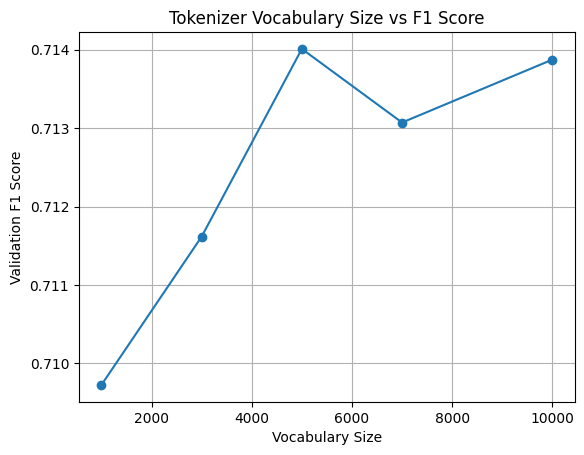

In [4]:
## LightningDataModule
class MyDataModule(pl.LightningDataModule):
    def __init__(self, ds, vocab_size: int = 5000, max_length: int = 256, batch_size: int = 32, num_workers: int = 2):
        super().__init__()
        self.ds = ds
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.batch_size = batch_size
        self.num_workers = num_workers

    def prepare_data(self):
        tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
        tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
        trainer = trainers.BpeTrainer(
            vocab_size=self.vocab_size,
            special_tokens=['[UNK]', '[PAD]']
        )
        tokenizer.train_from_iterator(self.ds['train']['text'], trainer=trainer)
        tokenizer.enable_padding(pad_token='[PAD]')
        tokenizer.enable_truncation(max_length=self.max_length)
        self.tokenizer = tokenizer

    def collate_fn(self, batch):
        input_ids = [self.tokenizer.encode(x['text']).ids for x in batch]
        input_ids = torch.nn.utils.rnn.pad_sequence([torch.tensor(ids) for ids in input_ids],
                                                    batch_first=True,
                                                    padding_value=self.tokenizer.token_to_id('[PAD]'))
        labels = torch.tensor([x['label'] for x in batch])
        return {'input_ids': input_ids, 'labels': labels}

    def train_dataloader(self):
        return DataLoader(self.ds['train'], batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, collate_fn=self.collate_fn)

    def val_dataloader(self):
        return DataLoader(self.ds['val'], batch_size=self.batch_size,
                          num_workers=self.num_workers, collate_fn=self.collate_fn)

## RNN Model
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=0)
        self.rnn = nn.GRU(embd_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.loss_fn = nn.CrossEntropyLoss()
        self.metric = torchmetrics.F1Score(task="multiclass", num_classes=2, average="macro")

    def forward(self, x):
        x = self.embedding(x)
        _, h = self.rnn(x)
        out = self.fc(h.squeeze(0))
        return out

    def training_step(self, batch, batch_idx):
        logits = self.forward(batch['input_ids'])
        loss = self.loss_fn(logits, batch['labels'])
        preds = torch.argmax(logits, dim=1)
        f1 = self.metric(preds, batch['labels'])
        self.log("train_f1", f1, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        logits = self.forward(batch['input_ids'])
        loss = self.loss_fn(logits, batch['labels'])
        preds = torch.argmax(logits, dim=1)
        f1 = self.metric(preds, batch['labels'])
        self.log("val_f1", f1, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

## Эксперименты
results = []
for vocab_size in [1000, 3000, 5000, 7000, 10000]:
    print(f"Training with vocab size: {vocab_size}")
    dm = MyDataModule(ds, vocab_size=vocab_size)
    dm.prepare_data()
    model = RNNModel(vocab_size=vocab_size, embd_size=128, hidden_size=128, output_size=2)
    trainer = pl.Trainer(max_epochs=5, enable_checkpointing=False, logger=False)
    trainer.fit(model, datamodule=dm)
    val_result = trainer.validate(model, datamodule=dm)[0]
    results.append((vocab_size, val_result['val_f1']))

## Plot results
vocab_sizes, f1_scores = zip(*results)
plt.plot(vocab_sizes, f1_scores, marker='o')
plt.xlabel("Vocabulary Size")
plt.ylabel("Validation F1 Score")
plt.title("Tokenizer Vocabulary Size vs F1 Score")
plt.grid(True)
plt.show()